## Some integrations

Now let's try to test the NS version of the code

In [1]:
import numpy as np 
import matplotlib.pyplot as plt

import precession_NS as pre_ns #my version of precession with NS spin precession eqautions
import precession as pre # classic precession 

### Intial condtion: no biforcation

In [ ]:
#this function randomly selects the spin angles considering an isotropic distribution
theta1, theta2, deltaphi=pre.isotropic_angles(N=1)

r0=100
q=0.3
chi1=0.1
chi2=0.3

deltachi=pre.eval_deltachi(theta1, theta2, q, chi1, chi2 )
kappa = pre.eval_kappa(theta1=theta1,theta2=theta2,deltaphi=deltaphi,r=r0,q=q,chi1=chi1,chi2=chi2)
lambda_1, lambda_2=248.32270941042592, 392.5220980348509
k1=pre_ns.eval_k_from_lambda(lambda_1)
k2=pre_ns.eval_k_from_lambda(lambda_2 )
# THESe NUMBERS ARE RANDOM!!
chicons= pre_ns.eval_chicons(theta1, theta2, r0, q, chi1, chi2, k1, k2 )
print(chicons, k1,k2)


[0.08774665] 4.756811769383652 5.494318648304815


In [ ]:
r=np.logspace(np.log10(r0),1,1000)
outputsNSorb = pre_ns.inspiral_orbav(theta1=theta1, theta2=theta2, deltaphi=deltaphi,q=q,r=r,chi1=chi1,chi2=chi2, k1=k1,k2=k2)
outputsNSpre = pre_ns.inspiral_precav(theta1=theta1, theta2=theta2, deltaphi=deltaphi,q=q,r=r,chi1=chi1,chi2=chi2, k1=k1,k2=k2)
 #it takes more time to evolve the precession average equations than the orbit average ones ( It should be the opposite :,)  ) 


True True True


In [4]:
chieffprecav0=pre.eval_chieff(outputsNSpre['theta1'][0],outputsNSpre['theta2'][0],outputsNSpre['q'][0],outputsNSpre['chi1'][0],outputsNSpre['chi2'][0])
chieffobrav0=pre.eval_chieff(outputsNSorb['theta1'][0],outputsNSorb['theta2'][0],outputsNSorb['q'][0],outputsNSorb['chi1'][0],outputsNSorb['chi2'][0])



Text(0.5, 0, '$r$')

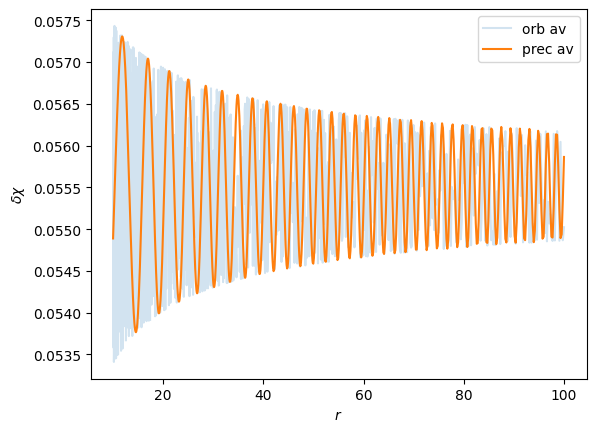

In [ ]:
#The important thing is the precision-averaged results are denser than orbit-averaged ones, and everything must stay within the same boundaries
plt.plot(outputsNSpre['r'][0],outputsNSpre['deltachi'][0],alpha=0.2, label='orb av')
plt.plot(outputsNSorb['r'][0],outputsNSorb['deltachi'][0], label='prec av')
plt.legend()
plt.ylabel(r'$\delta \chi$')
plt.xlabel('$r$')


Text(0.5, 0, '$r$')

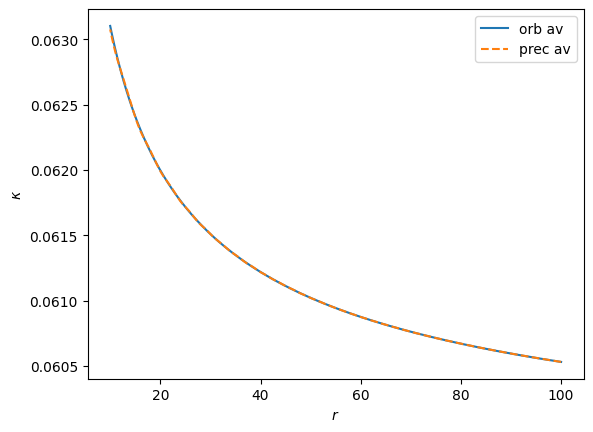

In [ ]:
plt.plot(outputsNSpre['r'][0],outputsNSpre['kappa'][0], label='orb av')
plt.plot(outputsNSorb['r'][0],outputsNSorb['kappa'][0],ls='--' ,label='prec av')
plt.legend()
plt.ylabel(r'$\kappa$')
plt.xlabel('$r$')

Text(0.5, 0, '$r$')

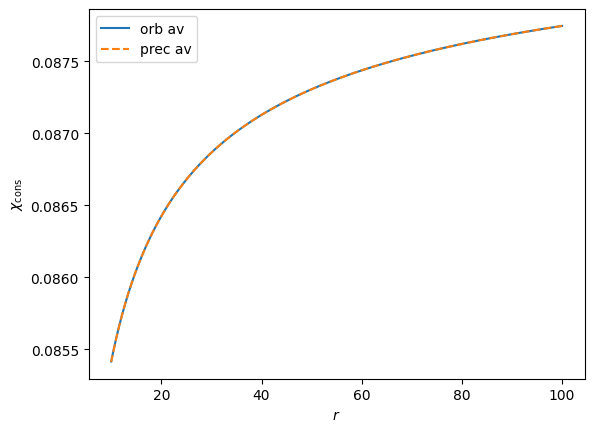

In [9]:
plt.plot(outputsNSpre['r'][0],outputsNSpre['chicons'][0],label='orb av')
plt.plot(outputsNSorb['r'][0],outputsNSorb['chicons'][0],ls='--',label='prec av')
plt.legend()
plt.ylabel(r'$ \chi_{\rm cons}$')
plt.xlabel('$r$')

Text(0.5, 0, '$r$')

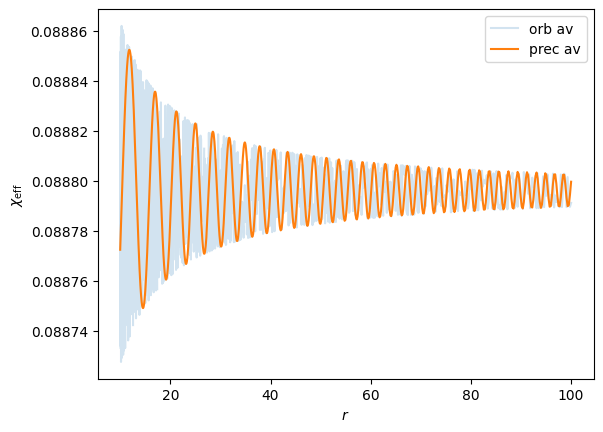

In [ ]:
#The important thing is the precision-averaged results are denser than orbit-averaged ones, and everything must stay within the same boundaries

plt.plot(outputsNSpre['r'][0],chieffprecav0,alpha=0.2, label='orb av')
plt.plot(outputsNSorb['r'][0],chieffobrav0, label='prec av')
plt.legend()
plt.ylabel(r'$\chi_{\rm eff}$')
plt.xlabel('$r$')

### Intial condtion: biforcation

In [ ]:
chicons0=-0.145
k0=-0.020
q=1.
chi1=0.5
chi2=0.6
k1=10 #very high!
k2=10.
rd=np.linspace(10,50,1000 ) #going backward in time toward large separations. At r=43.35 M, there is a bifurcation, and the code is not able to deal with this one [in principle it should] :(    
outputsNS = pre_ns.inspiral_precav(kappa=k0,r=rd,chicons=chicons0,q=q,chi1=chi1,chi2=chi2, k1=k1,k2=k2)
# This is my output. I asked to the root-finding function to print anytime we have 4 roots. The code is able to find them, but then it breaks.
#  I don't think it makes any sense that the code keeps finding 4 roots. There must be some numerical thing at play


/Users/giuliafumagalli/Documents/GitHub/spinningNS/code_giulia/precession_NS.py:748: RuntimeWarning: invalid value encountered in sqrt
  ((2 * (r)**(1/2) + (deltachi + (k2 * deltachi + -1 * ((4 * r + ((1 + \
/Users/giuliafumagalli/Documents/GitHub/spinningNS/code_giulia/precession_NS.py:755: RuntimeWarning: invalid value encountered in sqrt
  (chi2)**(-2) * ((-2 * (r)**(1/2) + (deltachi + (k1 * deltachi + ((4 * \
/Users/giuliafumagalli/Documents/GitHub/spinningNS/code_giulia/precession_NS.py:763: RuntimeWarning: invalid value encountered in sqrt
  (deltachi + (k2 * deltachi + -1 * ((4 * r + ((1 + -1 * k1 * k2) * \
/Users/giuliafumagalli/Documents/GitHub/spinningNS/code_giulia/precession_NS.py:768: RuntimeWarning: invalid value encountered in sqrt
  (deltachi + (k1 * deltachi + ((4 * r + ((1 + -1 * k1 * k2) * \
/Users/giuliafumagalli/Documents/GitHub/spinningNS/code_giulia/precession_NS.py:776: RuntimeWarning: invalid value encountered in sqrt
  (((4 * r + ((1 + -1 * k1 * k2) * (deltach

4 roots at: -0.037582463302232624 [43.31960384] -0.12600436069289492
4 roots at: -0.03758250542425901 [43.31960384] -0.1260044433563789
4 roots at: -0.037590674931541966 [43.35417461] -0.12600058243812923
4 roots at: -0.03760209268021284 [43.40932989] -0.12599130015744556


ValueError: zero-size array to reduction operation maximum which has no identity

In [ ]:
chicons0=-0.145
k0=-0.020
q=1.
chi1=0.5
chi2=0.6
k1=10 #very high!
k2=10.
rd=np.linspace(10,43.3,1000 ) #going backward in time just before the bifurcation
outputsNS = pre_ns.inspiral_precav(kappa=k0,r=rd,chicons=chicons0,q=q,chi1=chi1,chi2=chi2, k1=k1,k2=k2)


/Users/giuliafumagalli/Documents/GitHub/spinningNS/code_giulia/precession_NS.py:748: RuntimeWarning: invalid value encountered in sqrt
  ((2 * (r)**(1/2) + (deltachi + (k2 * deltachi + -1 * ((4 * r + ((1 + \
/Users/giuliafumagalli/Documents/GitHub/spinningNS/code_giulia/precession_NS.py:755: RuntimeWarning: invalid value encountered in sqrt
  (chi2)**(-2) * ((-2 * (r)**(1/2) + (deltachi + (k1 * deltachi + ((4 * \
/Users/giuliafumagalli/Documents/GitHub/spinningNS/code_giulia/precession_NS.py:763: RuntimeWarning: invalid value encountered in sqrt
  (deltachi + (k2 * deltachi + -1 * ((4 * r + ((1 + -1 * k1 * k2) * \
/Users/giuliafumagalli/Documents/GitHub/spinningNS/code_giulia/precession_NS.py:768: RuntimeWarning: invalid value encountered in sqrt
  (deltachi + (k1 * deltachi + ((4 * r + ((1 + -1 * k1 * k2) * \
/Users/giuliafumagalli/Documents/GitHub/spinningNS/code_giulia/precession_NS.py:776: RuntimeWarning: invalid value encountered in sqrt
  (((4 * r + ((1 + -1 * k1 * k2) * (deltach

In [ ]:

t1=outputsNS['theta1'][0][0]
t2=outputsNS['theta2'][0][0]
deltaphi=outputsNS['deltaphi'][0][0]
# evolve the same binary with orbit-averaged only equations 
outputsNSorb = pre_ns.inspiral_orbav(theta1=t1, theta2=t2, deltaphi=deltaphi,q=q,r=rd,chi1=chi1,chi2=chi2, k1=k1,k2=k2)


True True True


Text(0.5, 0, '$r$')

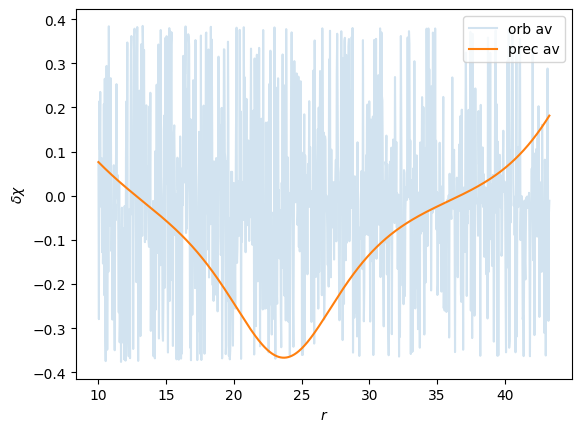

In [ ]:
#The important thing is the precision-averaged results are denser than orbit-averaged ones, and everything must stay within the same boundaries
plt.plot(outputsNS['r'][0],outputsNS['deltachi'][0],alpha=0.2, label='orb av')
plt.plot(outputsNSorb['r'][0],outputsNSorb['deltachi'][0], label='prec av')
plt.legend()
plt.ylabel(r'$\delta \chi$')
plt.xlabel('$r$')

In [ ]:
print(t1,t2,deltaphi)
rd=np.linspace(10,100,1000 ) #Looking at the same binary but evolved backward for a bit longer. We will cross the bifurcation so we can check if anything happen at all in the orb-averaged evolution

outputsNSorblong = pre_ns.inspiral_orbav(theta1=t1, theta2=t2, deltaphi=deltaphi,q=q,r=rd,chi1=chi1,chi2=chi2, k1=k1,k2=k2)


1.6775889462614382 1.921025671711283 0.463746001158507
True True True


Text(0.5, 0, '$r$')

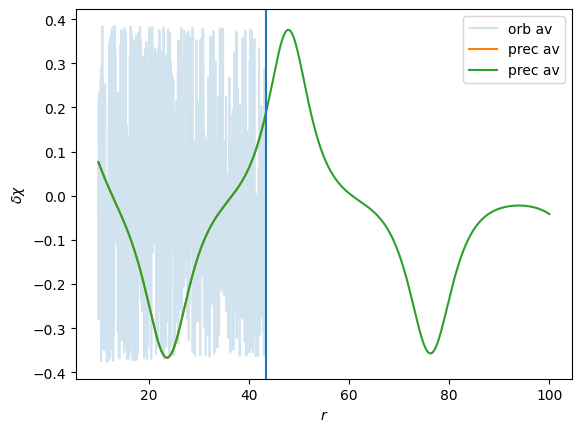

In [28]:
plt.plot(outputsNS['r'][0],outputsNS['deltachi'][0],alpha=0.2, label='orb av')
plt.plot(outputsNSorb['r'][0],outputsNSorb['deltachi'][0], label='prec av')
plt.plot(outputsNSorblong['r'][0],outputsNSorblong['deltachi'][0], label='prec av')
plt.legend()
plt.axvline(43.35)
plt.ylabel(r'$\delta \chi$')
plt.xlabel('$r$')

Text(0.5, 0, '$r$')

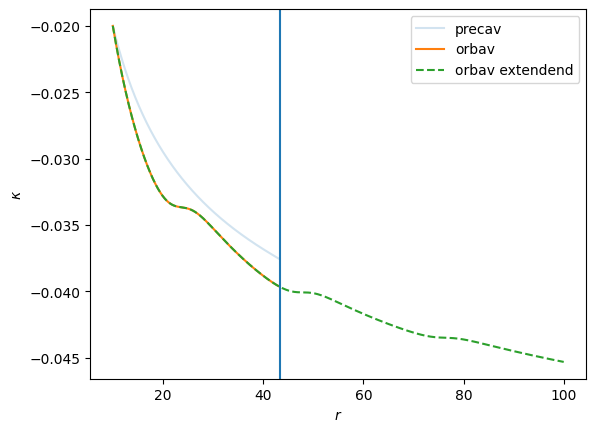

In [29]:
plt.plot(outputsNS['r'][0],outputsNS['kappa'][0],alpha=0.2, label='precav')
plt.plot(outputsNSorb['r'][0],outputsNSorb['kappa'][0], label='orbav')
plt.plot(outputsNSorblong['r'][0],outputsNSorblong['kappa'][0], label='orbav extendend', ls='--')
plt.legend()
plt.axvline(43.35)
plt.ylabel(r'$\kappa$')
plt.xlabel('$r$')

Text(0.5, 0, '$r$')

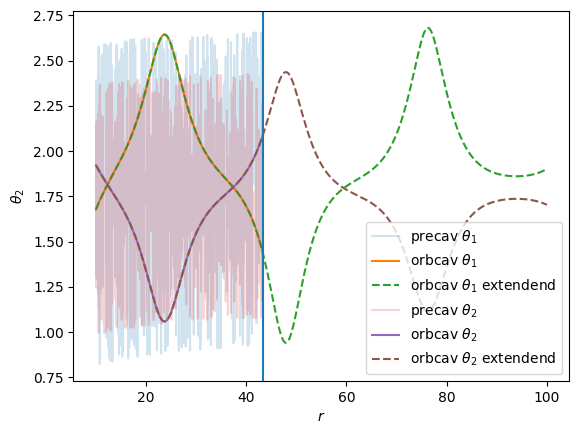

In [30]:
plt.plot(outputsNS['r'][0],outputsNS['theta1'][0],alpha=0.2, label=r'precav $\theta_1$')
plt.plot(outputsNSorb['r'][0],outputsNSorb['theta1'][0], label=r'orbcav $\theta_1$')
plt.plot(outputsNSorblong['r'][0],outputsNSorblong['theta1'][0], ls='--', label=r'orbcav $\theta_1$ extendend')

plt.plot(outputsNS['r'][0],outputsNS['theta2'][0],alpha=0.2, label=r'precav $\theta_2$')
plt.plot(outputsNSorb['r'][0],outputsNSorb['theta2'][0], label=r'orbcav $\theta_2$')
plt.plot(outputsNSorblong['r'][0],outputsNSorblong['theta2'][0],  ls='--',label=r'orbcav $\theta_2$ extendend')
plt.legend()
plt.axvline(43.35)
plt.ylabel(r'$\theta_2$')
plt.xlabel('$r$')

Text(0.5, 0, '$r$')

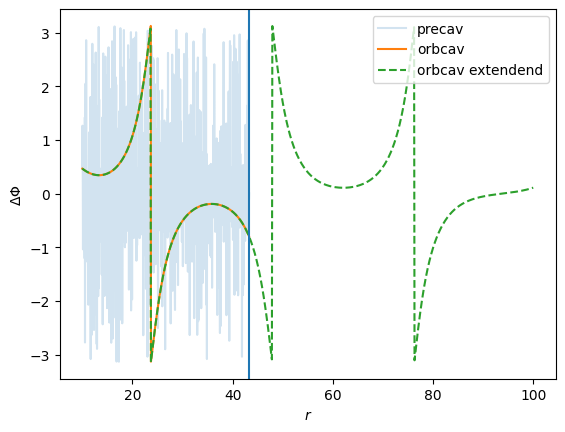

In [31]:
plt.plot(outputsNS['r'][0],outputsNS['deltaphi'][0],alpha=0.2, label=r'precav')
plt.plot(outputsNSorb['r'][0],outputsNSorb['deltaphi'][0], label=r'orbcav')
plt.plot(outputsNSorblong['r'][0],outputsNSorblong['deltaphi'][0], ls='--', label=r'orbcav extendend')

plt.legend()
plt.axvline(43.35)
plt.ylabel(r'$\Delta \Phi$')
plt.xlabel('$r$')

Text(0.5, 0, '$r$')

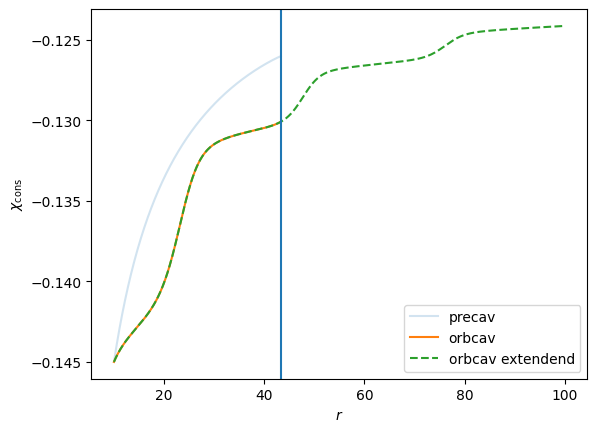

In [ ]:
plt.plot(outputsNS['r'][0],outputsNS['chicons'][0],alpha=0.2, label=r'precav')
plt.plot(outputsNSorb['r'][0],outputsNSorb['chicons'][0], label=r'orbcav')
plt.plot(outputsNSorblong['r'][0],outputsNSorblong['chicons'][0], ls='--', label=r'orbcav extendend')

plt.legend()
plt.axvline(43.35)
plt.ylabel(r'$\chi_{\rm cons}$')
plt.xlabel('$r$')

#there is something wrong here..

In [33]:
chieffprecav=pre.eval_chieff(outputsNS['theta1'][0],outputsNS['theta2'][0],outputsNS['q'][0],outputsNS['chi1'][0],outputsNS['chi2'][0])
chieffobrav=pre.eval_chieff(outputsNSorb['theta1'][0],outputsNSorb['theta2'][0],outputsNSorb['q'][0],outputsNSorb['chi1'][0],outputsNSorb['chi2'][0])
chiefforblong=pre.eval_chieff(outputsNSorblong['theta1'][0],outputsNSorblong['theta2'][0],outputsNSorblong['q'][0],outputsNSorblong['chi1'][0],outputsNSorblong['chi2'][0])



Text(0.5, 0, '$r$')

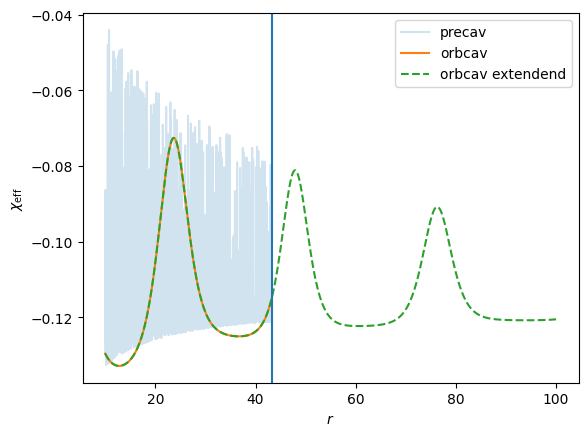

In [ ]:

plt.plot(outputsNS['r'][0],chieffprecav,alpha=0.2, label=r'precav')
plt.plot(outputsNSorb['r'][0],chieffobrav, label=r'orbcav')
plt.plot(outputsNSorblong['r'][0],chiefforblong, ls='--', label=r'orbcav extendend')

plt.legend()
plt.axvline(43.35)
plt.ylabel(r'$\chi_{\rm eff}$')
plt.xlabel('$r$')
#there is something wrong here..